In [5]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
from datetime import datetime
import os
import matplotlib.pyplot as plt
from open_ocean.utils import convert_climatology_to_ocean_areas
import open_ocean.gridder as gridder
import open_ocean.interpolation as io

In [6]:
def convert_dates(months, days):
    return [datetime(2020, months[i], days[i]) for i in range(len(months))]

In [7]:
def grid_selection(iquam, selection, climatology, sampling_unc, constant=None):
    id = iquam.platform_id.values[selection]
    type = iquam.platform_type.values[selection]
    lats = iquam.lat.values[selection]
    lons = iquam.lon.values[selection]
    values = iquam.sst.values[selection]

    # Convert dates
    dates = convert_dates(
        iquam.month.values[selection].astype(int),
        iquam.day.values[selection].astype(int)
    )

    # Grid up the data
    grid = gridder.Grid(2020, 10, id, lats, lons, dates, values, type, climatology)
    grid.add_sampling_uncertainties(sampling_unc)
    grid.do_1x1_gridding()
    grid.do_one_step_5x5_gridding()
    grid.calculate_covariance(constant=constant)

    return grid

In [8]:
data_dir = Path(os.getenv("OODIR"))
coder = xr.coders.CFDatetimeCoder(time_unit="s")

In [9]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
areas = convert_climatology_to_ocean_areas(climatology)
sampling_unc = xr.open_dataset(data_dir / "IQUAM" / "OutputData" / "sampling_uncertainty.nc")

In [10]:
year = 2008
month = 7
file = data_dir / 'IQUAM' / f'{year}{month:02d}-STAR-L2i_GHRSST-SST-iQuam-V2.10-v01.0-fv01.0.nc'
iquam = xr.open_dataset(file, decode_timedelta=coder)

quality = iquam.quality_level.values
selection = (quality >= 4)

grid = grid_selection(iquam, selection, climatology, sampling_unc)


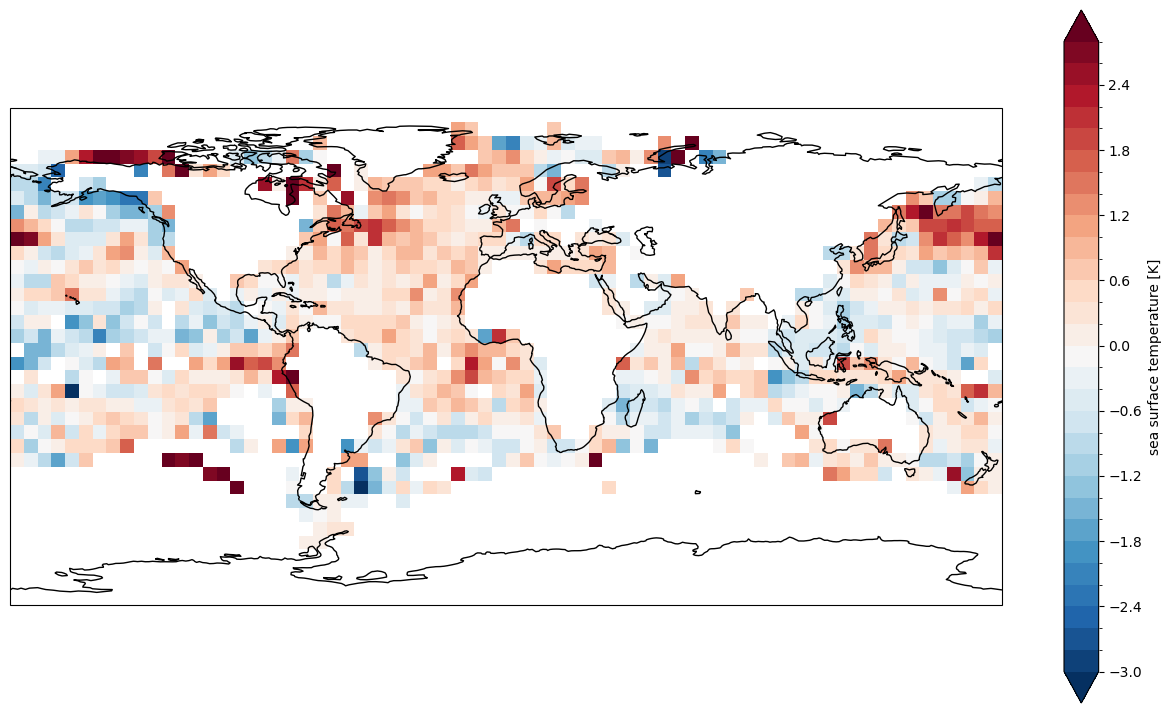

In [17]:
selection = (quality >= 4) & (iquam.platform_type.values == 1)
ship_grid = grid_selection(iquam, selection, climatology, sampling_unc, constant=0.2)
ship_grid.plot_map_5x5()

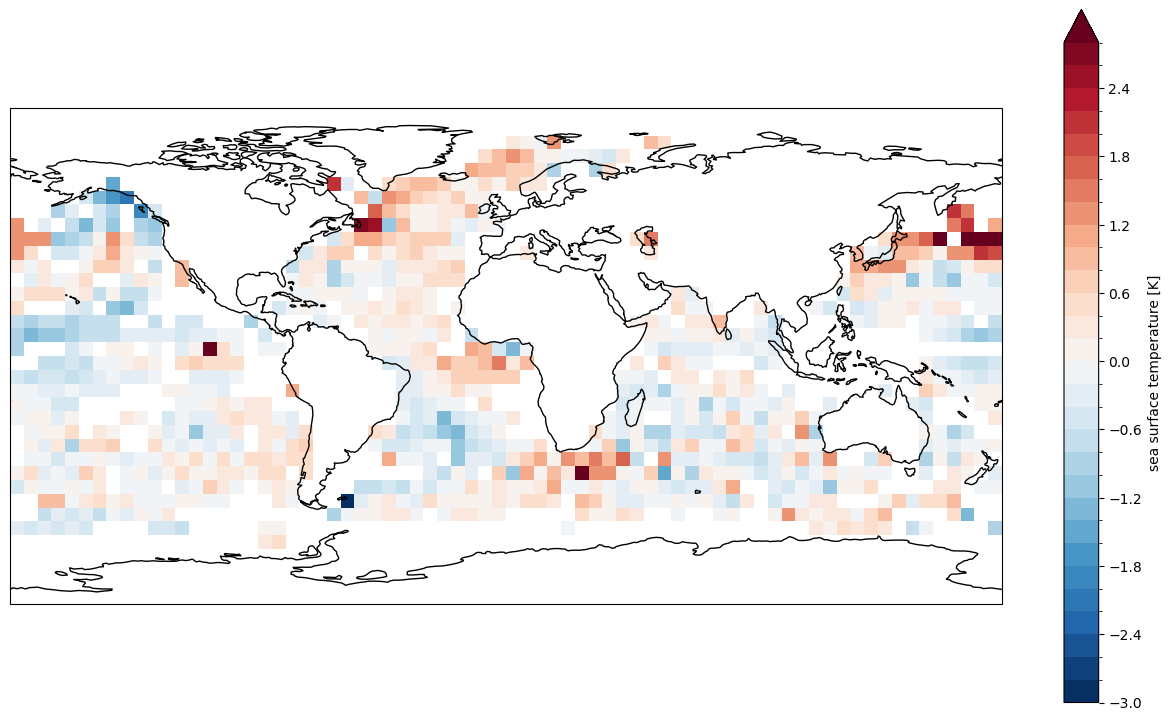

In [18]:
selection = (quality >= 4) & (iquam.platform_type.values == 2)
drifter_grid = grid_selection(iquam, selection, climatology, sampling_unc)
drifter_grid.plot_map_5x5()

In [13]:
kernel = io.Kernel(0.6, 1300.0, 1.5)
interp1 = io.GPInterpolator(drifter_grid, kernel)
interp1.make_covariance(constant=0.2)
interpolated_grid1 = interp1.do_interpolation()
interpolated_grid1.data5[np.isnan(sampling_unc.sst.values[0:1, :, :])] = np.nan

C:\Users\johnk\PycharmProjects\open-ocean\open_ocean\interpolation.py:37: RuntimeWarning: invalid value encountered in multiply
  (self.variance ** 2) *


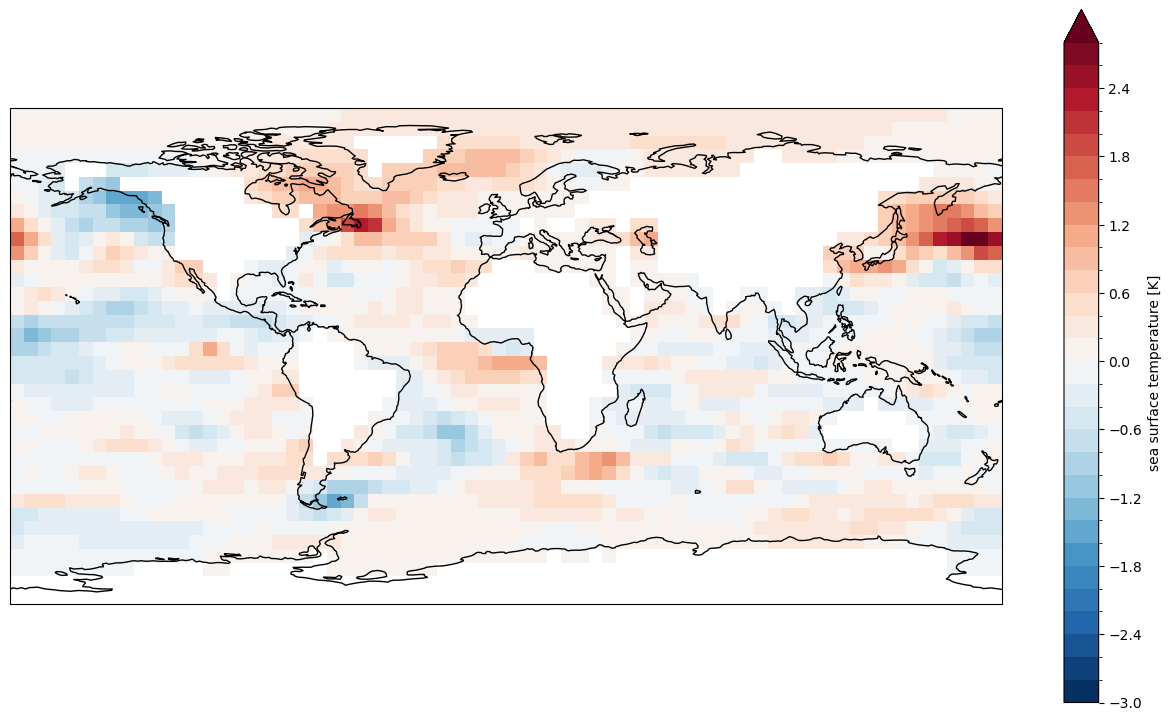

In [16]:
interpolated_grid1.plot_map_5x5()

In [14]:
ship_grid = ship_grid - interpolated_grid1

kernel = io.Kernel(0.6, 1300.0, 1.5)
interp2 = io.GPInterpolator(ship_grid, kernel)
interp2.add_covariance(interp1.posterior)
interpolated_grid2 = interp2.do_interpolation()
interpolated_grid2.data5[np.isnan(sampling_unc.sst.values[0:1, :, :])] = np.nan

interpolated_grid2 = interpolated_grid2 + interpolated_grid1


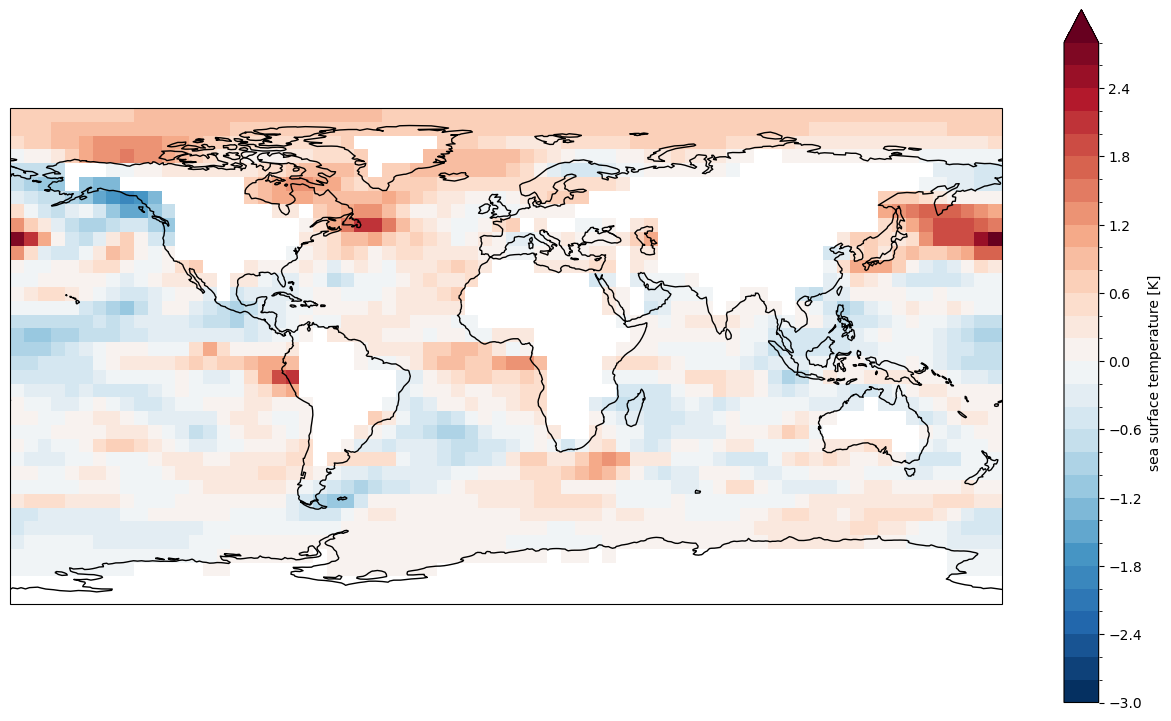

In [15]:
interpolated_grid2.plot_map_5x5()

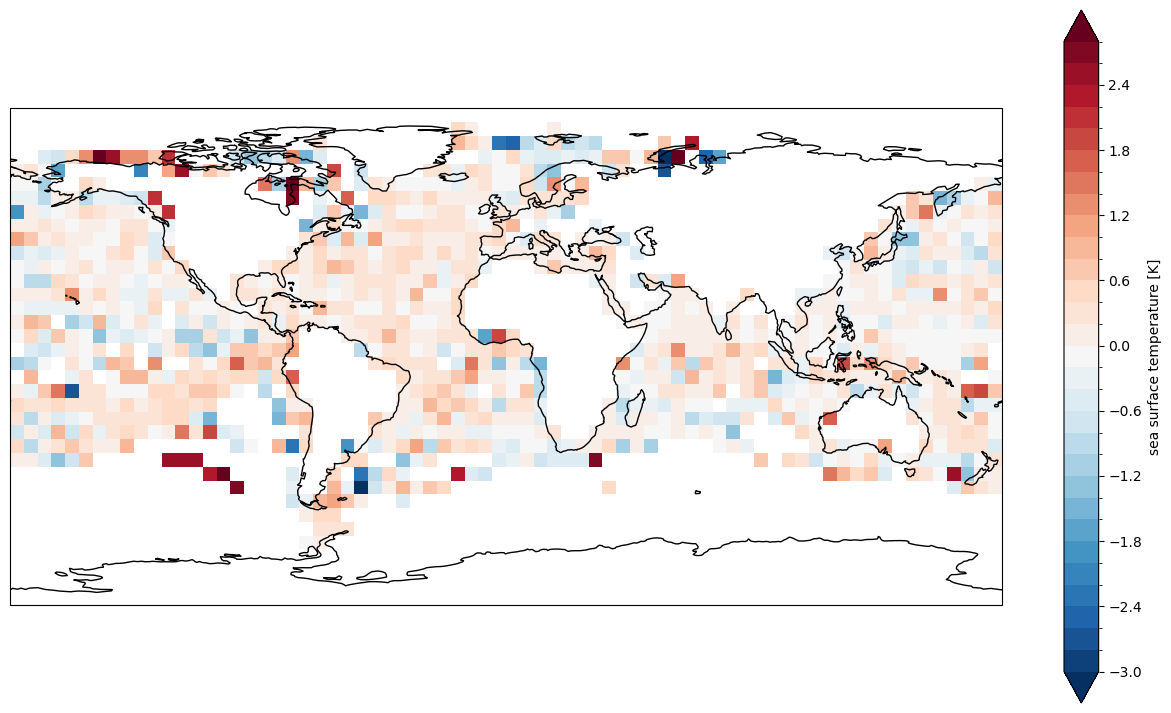

In [19]:
ship_error = ship_grid - interpolated_grid2
ship_error.plot_map_5x5()